Running game 1/50
Running game 2/50
Running game 3/50
Running game 4/50
Running game 5/50
Running game 6/50
Running game 7/50
Running game 8/50
Running game 9/50
Running game 10/50
Running game 11/50
Running game 12/50
Running game 13/50
Running game 14/50
Running game 15/50
Running game 16/50
Running game 17/50
Running game 18/50
Running game 19/50
Running game 20/50
Running game 21/50
Running game 22/50
Running game 23/50
Running game 24/50
Running game 25/50
Running game 26/50
Running game 27/50
Running game 28/50
Running game 29/50
Running game 30/50
Running game 31/50
Running game 32/50
Running game 33/50
Running game 34/50
Running game 35/50
Running game 36/50
Running game 37/50
Running game 38/50
Running game 39/50
Running game 40/50
Running game 41/50
Running game 42/50
Running game 43/50
Running game 44/50
Running game 45/50
Running game 46/50
Running game 47/50
Running game 48/50
Running game 49/50
Running game 50/50


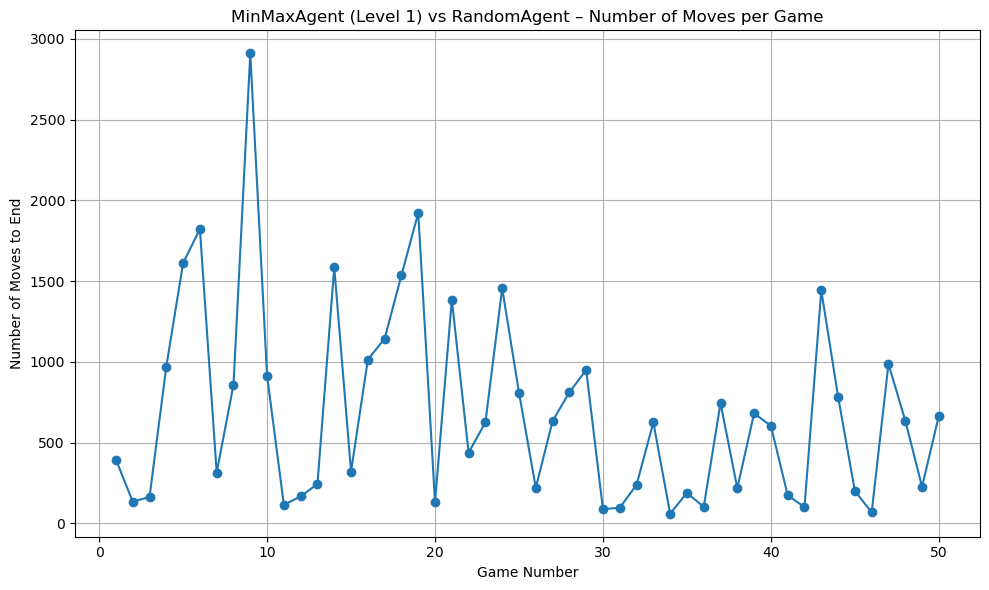

In [9]:
#!/usr/bin/env python
import pygame
import random
import os
import matplotlib.pyplot as plt
from core.chessRules import Rules
from agents.random_agent import RandomAgent
from agents.minmax_agent import MinMaxAgent

OUTPUT_DIR = "results/level1_vs_random"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def run_single_game(game_index):
    pygame.init()
    game = Rules()
    white_agent = MinMaxAgent('white', game, level=1)
    black_agent = RandomAgent('black', game)
    player_turn = random.choice(['white', 'black'])
    move_count = 0
    log_lines = []

    while True:
        move_count += 1
        log_lines.append(f"Move {move_count}, turn: {player_turn}")

        if player_turn == 'white':
            move = white_agent.select_move()
            if move is None:
                log_lines.append("White agent has no moves left! Game over.")
                result = "black_win"
                break
            piece, to_pos = move
            log_lines.append(f"White moves {piece} to {to_pos}")
            game.make_move(piece, to_pos)
        else:
            move = black_agent.select_move()
            if move is None:
                log_lines.append("Black agent has no moves left! Game over.")
                result = "white_win"
                break
            piece, to_pos = move
            log_lines.append(f"Black moves {piece} to {to_pos}")
            game.make_move(piece, to_pos)

        white_status = game.check_status('white')
        black_status = game.check_status('black')

        if white_status == "draw" or black_status == "draw":
            log_lines.append("Draw! Insufficient material.")
            result = "draw"
            break
        if white_status == "checkmate":
            log_lines.append("Checkmate! White loses.")
            result = "black_win"
            break
        if black_status == "checkmate":
            log_lines.append("Checkmate! Black loses.")
            result = "white_win"
            break

        player_turn = 'black' if player_turn == 'white' else 'white'

    pygame.quit()
    # Ghi file log theo định dạng yêu cầu
    file_path = os.path.join(OUTPUT_DIR, f"game_{game_index+1}.txt")
    with open(file_path, "w") as f:
        for line in log_lines:
            f.write(line + "\n")
    return move_count

def run_simulations(n_games=50):
    move_counts = []
    for i in range(n_games):
        print(f"Running game {i+1}/{n_games}")
        moves = run_single_game(i)
        move_counts.append(moves)
    return move_counts

def plot_results(move_counts):
    x = list(range(1, len(move_counts) + 1))
    y = move_counts

    plt.figure(figsize=(10, 6))
    plt.plot(x, y, marker='o')
    plt.xlabel("Game Number")
    plt.ylabel("Number of Moves to End")
    plt.title("MinMaxAgent (Level 1) vs RandomAgent – Number of Moves per Game")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    move_counts = []
    minmax_wins = 0

    for i in range(50):
        print(f"Running game {i+1}/50")
        moves = run_single_game(i)
        move_counts.append(moves)

        # read results from file game_i.txt
        file_path = os.path.join(OUTPUT_DIR, f"game_{i+1}.txt")
        with open(file_path, "r") as f:
            lines = f.readlines()
            if lines and "Checkmate! Black loses." in lines[-1]:
                minmax_wins += 1

    # note in average_moves.txt
    avg_moves = sum(move_counts) / len(move_counts)
    with open(os.path.join(OUTPUT_DIR, "average_moves.txt"), "w") as f:
        f.write(f"Average number of moves over 50 games: {avg_moves:.2f}\n")
        f.write(f"MinMaxAgent (white) wins: {minmax_wins} out of 50 games\n")

    plot_results(move_counts)

Running game 1/50
Running game 2/50
Running game 3/50
Running game 4/50
Running game 5/50
Running game 6/50
Running game 7/50
Running game 8/50
Running game 9/50
Running game 10/50
Running game 11/50
Running game 12/50
Running game 13/50
Running game 14/50
Running game 15/50
Running game 16/50
Running game 17/50
Running game 18/50
Running game 19/50
Running game 20/50
Running game 21/50
Running game 22/50
Running game 23/50
Running game 24/50
Running game 25/50
Running game 26/50
Running game 27/50
Running game 28/50
Running game 29/50
Running game 30/50
Running game 31/50
Running game 32/50
Running game 33/50
Running game 34/50
Running game 35/50
Running game 36/50
Running game 37/50
Running game 38/50
Running game 39/50
Running game 40/50
Running game 41/50
Running game 42/50
Running game 43/50
Running game 44/50
Running game 45/50
Running game 46/50
Running game 47/50
Running game 48/50
Running game 49/50
Running game 50/50


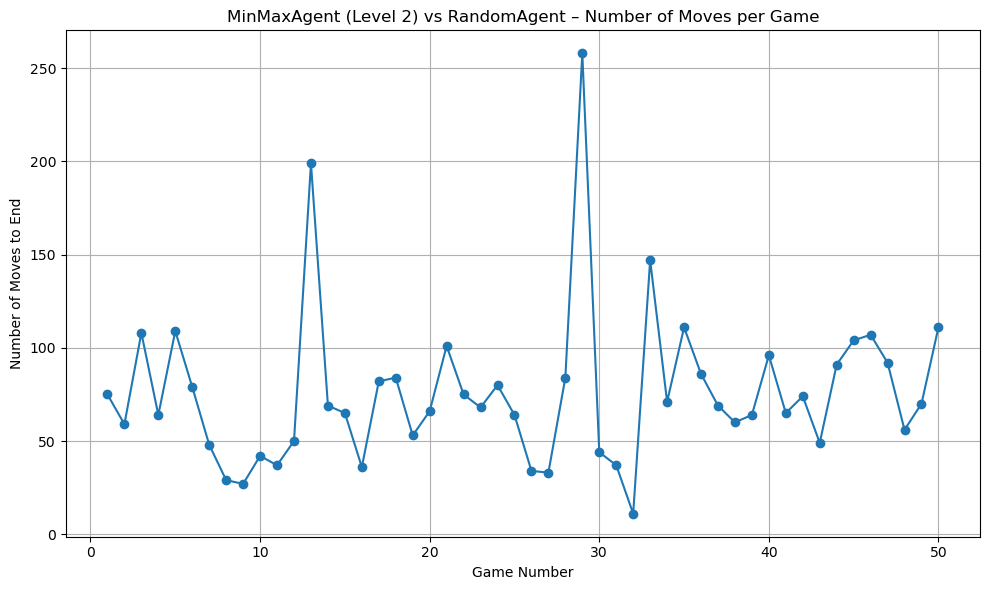

In [14]:
#!/usr/bin/env python
import pygame
import random
import os
import matplotlib.pyplot as plt
from core.chessRules import Rules
from agents.random_agent import RandomAgent
from agents.minmax_agent import MinMaxAgent

OUTPUT_DIR = "results/level2_vs_random"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def run_single_game(game_index):
    pygame.init()
    game = Rules()
    white_agent = MinMaxAgent('white', game, level=2)
    black_agent = RandomAgent('black', game)
    player_turn = random.choice(['white', 'black'])
    move_count = 0
    log_lines = []

    while True:
        move_count += 1
        log_lines.append(f"Move {move_count}, turn: {player_turn}")

        if player_turn == 'white':
            move = white_agent.select_move()
            if move is None:
                log_lines.append("White agent has no moves left! Game over.")
                result = "black_win"
                break
            piece, to_pos = move
            log_lines.append(f"White moves {piece} to {to_pos}")
            game.make_move(piece, to_pos)
        else:
            move = black_agent.select_move()
            if move is None:
                log_lines.append("Black agent has no moves left! Game over.")
                result = "white_win"
                break
            piece, to_pos = move
            log_lines.append(f"Black moves {piece} to {to_pos}")
            game.make_move(piece, to_pos)

        white_status = game.check_status('white')
        black_status = game.check_status('black')

        if white_status == "draw" or black_status == "draw":
            log_lines.append("Draw! Insufficient material.")
            result = "draw"
            break
        if white_status == "checkmate":
            log_lines.append("Checkmate! White loses.")
            result = "black_win"
            break
        if black_status == "checkmate":
            log_lines.append("Checkmate! Black loses.")
            result = "white_win"
            break

        player_turn = 'black' if player_turn == 'white' else 'white'

    pygame.quit()
    # Ghi file log theo định dạng yêu cầu
    file_path = os.path.join(OUTPUT_DIR, f"game_{game_index+1}.txt")
    with open(file_path, "w") as f:
        for line in log_lines:
            f.write(line + "\n")
    return move_count

def run_simulations(n_games=50):
    move_counts = []
    for i in range(n_games):
        print(f"Running game {i+1}/{n_games}")
        moves = run_single_game(i)
        move_counts.append(moves)
    return move_counts

def plot_results(move_counts):
    x = list(range(1, len(move_counts) + 1))
    y = move_counts

    plt.figure(figsize=(10, 6))
    plt.plot(x, y, marker='o')
    plt.xlabel("Game Number")
    plt.ylabel("Number of Moves to End")
    plt.title("MinMaxAgent (Level 2) vs RandomAgent – Number of Moves per Game")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    move_counts = []
    minmax_wins = 0

    for i in range(50):
        print(f"Running game {i+1}/50")
        moves = run_single_game(i)
        move_counts.append(moves)

        # read results from file game_i.txt
        file_path = os.path.join(OUTPUT_DIR, f"game_{i+1}.txt")
        with open(file_path, "r") as f:
            lines = f.readlines()
            if lines and "Checkmate! Black loses." in lines[-1]:
                minmax_wins += 1

    # note in average_moves.txt
    avg_moves = sum(move_counts) / len(move_counts)
    with open(os.path.join(OUTPUT_DIR, "average_moves.txt"), "w") as f:
        f.write(f"Average number of moves over 50 games: {avg_moves:.2f}\n")
        f.write(f"MinMaxAgent (white) wins: {minmax_wins} out of 50 games\n")

    plot_results(move_counts)


Running game 1/50
Running game 2/50
Running game 3/50
Running game 4/50
Running game 5/50
Running game 6/50
Running game 7/50
Running game 8/50
Running game 9/50
Running game 10/50
Running game 11/50
Running game 12/50
Running game 13/50
Running game 14/50
Running game 15/50
Running game 16/50
Running game 17/50
Running game 18/50
Running game 19/50
Running game 20/50
Running game 21/50
Running game 22/50
Running game 23/50
Running game 24/50
Running game 25/50
Running game 26/50
Running game 27/50
Running game 28/50
Running game 29/50
Running game 30/50
Running game 31/50
Running game 32/50
Running game 33/50
Running game 34/50
Running game 35/50
Running game 36/50
Running game 37/50
Running game 38/50
Running game 39/50
Running game 40/50
Running game 41/50
Running game 42/50
Running game 43/50
Running game 44/50
Running game 45/50
Running game 46/50
Running game 47/50
Running game 48/50
Running game 49/50
Running game 50/50


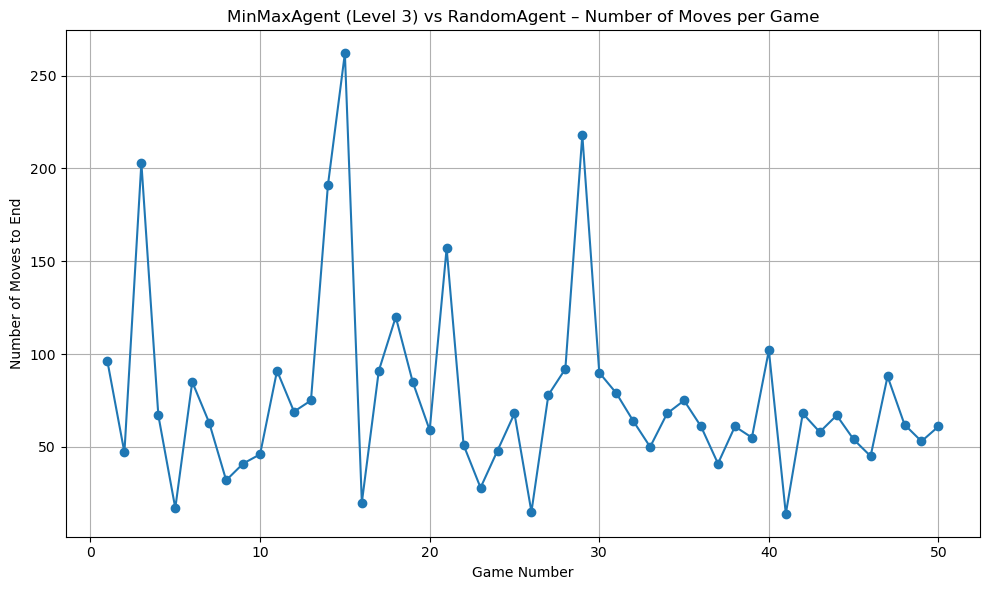

In [10]:
#!/usr/bin/env python
import pygame
import random
import os
import matplotlib.pyplot as plt
from core.chessRules import Rules
from agents.random_agent import RandomAgent
from agents.minmax_agent import MinMaxAgent

OUTPUT_DIR = "results/level3_vs_random"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def run_single_game(game_index):
    pygame.init()
    game = Rules()
    white_agent = MinMaxAgent('white', game, level=3)
    black_agent = RandomAgent('black', game)
    player_turn = random.choice(['white', 'black'])
    move_count = 0
    log_lines = []

    while True:
        move_count += 1
        log_lines.append(f"Move {move_count}, turn: {player_turn}")

        if player_turn == 'white':
            move = white_agent.select_move()
            if move is None:
                log_lines.append("White agent has no moves left! Game over.")
                result = "black_win"
                break
            piece, to_pos = move
            log_lines.append(f"White moves {piece} to {to_pos}")
            game.make_move(piece, to_pos)
        else:
            move = black_agent.select_move()
            if move is None:
                log_lines.append("Black agent has no moves left! Game over.")
                result = "white_win"
                break
            piece, to_pos = move
            log_lines.append(f"Black moves {piece} to {to_pos}")
            game.make_move(piece, to_pos)

        white_status = game.check_status('white')
        black_status = game.check_status('black')

        if white_status == "draw" or black_status == "draw":
            log_lines.append("Draw! Insufficient material.")
            result = "draw"
            break
        if white_status == "checkmate":
            log_lines.append("Checkmate! White loses.")
            result = "black_win"
            break
        if black_status == "checkmate":
            log_lines.append("Checkmate! Black loses.")
            result = "white_win"
            break

        player_turn = 'black' if player_turn == 'white' else 'white'

    pygame.quit()
    # Ghi file log theo định dạng yêu cầu
    file_path = os.path.join(OUTPUT_DIR, f"game_{game_index+1}.txt")
    with open(file_path, "w") as f:
        for line in log_lines:
            f.write(line + "\n")
    return move_count

def run_simulations(n_games=50):
    move_counts = []
    for i in range(n_games):
        print(f"Running game {i+1}/{n_games}")
        moves = run_single_game(i)
        move_counts.append(moves)
    return move_counts

def plot_results(move_counts):
    x = list(range(1, len(move_counts) + 1))
    y = move_counts

    plt.figure(figsize=(10, 6))
    plt.plot(x, y, marker='o')
    plt.xlabel("Game Number")
    plt.ylabel("Number of Moves to End")
    plt.title("MinMaxAgent (Level 3) vs RandomAgent – Number of Moves per Game")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    move_counts = []
    minmax_wins = 0

    for i in range(50):
        print(f"Running game {i+1}/50")
        moves = run_single_game(i)
        move_counts.append(moves)

        # read results from file game_i.txt
        file_path = os.path.join(OUTPUT_DIR, f"game_{i+1}.txt")
        with open(file_path, "r") as f:
            lines = f.readlines()
            if lines and "Checkmate! Black loses." in lines[-1]:
                minmax_wins += 1

    # note in average_moves.txt
    avg_moves = sum(move_counts) / len(move_counts)
    with open(os.path.join(OUTPUT_DIR, "average_moves.txt"), "w") as f:
        f.write(f"Average number of moves over 50 games: {avg_moves:.2f}\n")
        f.write(f"MinMaxAgent (white) wins: {minmax_wins} out of 50 games\n")

    plot_results(move_counts)
